In [57]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
import sys

sys.path.append("../../Modeling/fitting")
from optimization_utils import make_boundary, get_wmse

In [58]:
try:
    plt.rcParams["font.family"] = "Times New Roman"
except:
    from matplotlib import font_manager

    font_manager.fontManager.addfont("/home1/beigejin/Times.ttc")
    plt.rc("font", family="serif", serif=["Times"])
    plt.rcParams["mathtext.fontset"] = "custom"
    plt.rcParams["mathtext.rm"] = "Times"
plt.rcParams["font.size"] = 16
SAVEFIG = False
SAVERES = False

## Load Stimuli and Semantic Matrix

In [59]:
with open("simu7_data/simu7_design.pkl", "rb") as inp:
    df_study = pickle.load(inp)
    df_test = pickle.load(inp)
df_study = df_study.loc[df_study.session < 500]
df_test = df_test.loc[df_test.session < 500]

In [60]:
df_study

,study_itemno1,study_itemno2,study_item1,study_item2,serial_pos,list,session
0,110,1083,BED,PLANT,0,0,0
1,1262,1627,SEAL,WRITER,1,0,0
2,738,1198,INMATE,ROBE,2,0,0
3,187,748,BUG,JAM,3,0,0
4,1423,1072,SWORD,PIN,4,0,0
...,...,...,...,...,...,...,...
95995,1507,755,TRIGGER,JELLY,7,15,499
95996,1635,616,ZEBRA,FURNITURE,8,15,499
95997,1313,175,SKATE,BRIEFCASE,9,15,499
95998,981,1438,ORCHESTRA,TAXI,10,15,499


In [61]:
df_test

,test_itemno,test_item,correct_ans,study_pos,test_dir,list,session
0,324,CLIPPERS,823,9,1,0,0
1,1347,SPARROW,1051,8,1,0,0
2,413,CROSS,524,7,0,0,0
3,812,LEOPARD,1323,5,0,0,0
4,110,BED,1083,0,0,0,0
...,...,...,...,...,...,...,...
63995,1297,SHRIMP,1053,3,0,15,499
63996,1205,ROOF,1156,1,0,15,499
63997,1436,TART,488,11,0,15,499
63998,755,JELLY,1507,7,1,15,499


In [62]:
sem_mat = np.load("../wordpools/ltp_FR_similarity_matrix.npy")

## Run CMR-IA

In [63]:
# define parameters
params = cmr.make_default_params()
params.update(use_new_context=True, nitems_in_accumulator=96)

# load pso results
_, _, what_to_fit = make_boundary(sim_name="7")
optim_params = np.loadtxt("simu7_data/7_250311_200-200.txt")
for pname, pvalue in zip(what_to_fit, optim_params):
    params[pname] = pvalue
params

{'beta_enc': 0.845814,
 'beta_rec': 0.083332,
 'beta_cue': 0.693018,
 'beta_rec_post': 0.224431,
 'beta_distract': 0.219932,
 'phi_s': 1.496335,
 'phi_d': 0.013195,
 's_cf': 0.346849,
 's_fc': 0.3027,
 'kappa': 0.050411,
 'eta': 0.022039,
 'omega': 7.914679,
 'alpha': 0.961427,
 'lamb': 0.14727,
 'c_thresh': 0.364359,
 'c_thresh_itm': 0.5,
 'c_thresh_assoc': 0.5,
 'd_assoc': 1,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 96,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'use_new_context': True,
 'psi_s': 0,
 'psi_c': 1,
 'c_s': 0,
 'thresh_sigma': 0,
 'ban_recall': None,
 'var_enc': 1,
 'bad_enc_ratio': 1,
 'a': 2800,
 'b': 20,
 'gamma_fc': 0.776299,
 'gamma_cf': 0.488009}

In [64]:
# # define parameters
# params = cmr.make_default_params()
# params.update(
#     beta_enc=0.6,  # 0.6
#     beta_rec=0.1,
#     beta_cue=0.6,
#     beta_distract=0.1,
#     beta_rec_post=0.1,
#     gamma_fc=0.55,  # 0.4
#     gamma_cf=0.7,  # 0.6, cf - fc Higher, ILI +1 Higher
#     s_fc=0.15,  # 0.2
#     s_cf=0.15,  # 0.2
#     c_thresh=0.2,  # 0.01
#     kappa=0.04,  # 0.05
#     lamb=0.01,  # 0.02
#     eta=0.02,  # 0.02, raise it can diminish the diff between +1 and +2
#     omega=5,  # this is important for increasing PLI num
#     alpha=1,
#     phi_s=0.25,  # 0.3, control the plateau of left and right side of ILI
#     phi_d=0.5,
#     nitems_in_accumulator=96,  # 48
#     use_new_context=True,
# )
# params

In [65]:
for key in what_to_fit:
    print(f"{key}: {params[key]:.3f}")

beta_enc: 0.846
beta_rec: 0.083
beta_cue: 0.693
beta_rec_post: 0.224
beta_distract: 0.220
gamma_fc: 0.776
gamma_cf: 0.488
s_fc: 0.303
s_cf: 0.347
phi_s: 1.496
phi_d: 0.013
kappa: 0.050
lamb: 0.147
eta: 0.022
omega: 7.915
alpha: 0.961
c_thresh: 0.364


In [66]:
if SAVERES:
    # run CMR-IA
    df_simu, f_in, f_dif = cmr.run_norm_cr_multi_sess(params, df_study, df_test, sem_mat)

    # merge to get more info
    df_simu = df_simu.merge(df_test, on=["session", "list", "test_itemno"])
    df_simu["correct"] = df_simu.s_resp == df_simu.correct_ans

    # save
    df_simu.to_pickle("simu7_data/simu7_result.pkl")
else:
    # load results
    df_simu = pd.read_pickle("simu7_data/simu7_result.pkl")
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct
0,0,0,324,823,940,0.893475,CLIPPERS,823,9,1,True
1,0,0,1347,812,1760,0.704585,SPARROW,1051,8,1,False
2,0,0,413,524,1080,0.917445,CROSS,524,7,0,True
3,0,0,812,1323,2190,0.908466,LEOPARD,1323,5,0,True
4,0,0,110,1198,2280,0.704052,BED,1083,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...
63995,499,15,1297,-1,-1,-1.000000,SHRIMP,1053,3,0,False
63996,499,15,1205,1156,2010,0.926300,ROOF,1156,1,0,True
63997,499,15,1436,-1,-1,-1.000000,TART,488,11,0,False
63998,499,15,755,-1,-1,-1.000000,JELLY,1507,7,1,False


## Analysis

In [67]:
# get the study list and study pos of response
sessions = np.unique(df_simu.session)
nlist = len(np.unique(df_simu.list))
resp_study_list = []
resp_study_pos = []
for sess in sessions:

    pres_words = df_study.loc[df_study.session == sess, ["study_itemno1", "study_itemno2"]].to_numpy()
    pres_words = np.reshape(pres_words, (nlist, -1, 2))
    responses = df_simu.loc[df_simu.session == sess, "s_resp"]

    for r in responses:
        if r == -1 or r == -2:
            r_list = None
            r_pos = None
        else:
            r_list = np.where(pres_words == r)[0].item()
            r_pos = np.where(pres_words == r)[1].item()
        resp_study_list.append(r_list)
        resp_study_pos.append(r_pos)

df_simu["resp_study_list"] = resp_study_list
df_simu["resp_study_pos"] = resp_study_pos
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos
0,0,0,324,823,940,0.893475,CLIPPERS,823,9,1,True,0.0,9.0
1,0,0,1347,812,1760,0.704585,SPARROW,1051,8,1,False,0.0,5.0
2,0,0,413,524,1080,0.917445,CROSS,524,7,0,True,0.0,7.0
3,0,0,812,1323,2190,0.908466,LEOPARD,1323,5,0,True,0.0,5.0
4,0,0,110,1198,2280,0.704052,BED,1083,0,0,False,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
63995,499,15,1297,-1,-1,-1.000000,SHRIMP,1053,3,0,False,NaN,NaN
63996,499,15,1205,1156,2010,0.926300,ROOF,1156,1,0,True,15.0,1.0
63997,499,15,1436,-1,-1,-1.000000,TART,488,11,0,False,NaN,NaN
63998,499,15,755,-1,-1,-1.000000,JELLY,1507,7,1,False,NaN,NaN


In [68]:
# get intrution type
df_simu["list_lag"] = df_simu["resp_study_list"] - df_simu["list"]
df_simu["pos_lag"] = df_simu["resp_study_pos"] - df_simu["study_pos"]


def which_intrusion(x):
    x_list_lag = x["list_lag"]
    x_pos_lag = x["pos_lag"]

    if np.isnan(x_list_lag):
        return "NoResp"
    elif x_list_lag == 0 and x_pos_lag == 0:
        return "Correct"
    elif x_list_lag < 0:
        return "PLI"
    elif x_list_lag == 0 and x_pos_lag != 0:
        return "ILI"
    else:
        return np.nan


df_simu["intrusion_type"] = df_simu.apply(lambda x: which_intrusion(x), axis=1)
df_simu["intrusion_type"] = pd.Categorical(df_simu["intrusion_type"], categories=["NoResp", "Correct", "PLI", "ILI"])
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos,list_lag,pos_lag,intrusion_type
0,0,0,324,823,940,0.893475,CLIPPERS,823,9,1,True,0.0,9.0,0.0,0.0,Correct
1,0,0,1347,812,1760,0.704585,SPARROW,1051,8,1,False,0.0,5.0,0.0,-3.0,ILI
2,0,0,413,524,1080,0.917445,CROSS,524,7,0,True,0.0,7.0,0.0,0.0,Correct
3,0,0,812,1323,2190,0.908466,LEOPARD,1323,5,0,True,0.0,5.0,0.0,0.0,Correct
4,0,0,110,1198,2280,0.704052,BED,1083,0,0,False,0.0,2.0,0.0,2.0,ILI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63995,499,15,1297,-1,-1,-1.000000,SHRIMP,1053,3,0,False,NaN,NaN,NaN,NaN,NoResp
63996,499,15,1205,1156,2010,0.926300,ROOF,1156,1,0,True,15.0,1.0,0.0,0.0,Correct
63997,499,15,1436,-1,-1,-1.000000,TART,488,11,0,False,NaN,NaN,NaN,NaN,NoResp
63998,499,15,755,-1,-1,-1.000000,JELLY,1507,7,1,False,NaN,NaN,NaN,NaN,NoResp


In [69]:
# clean list 1
df_simu = df_simu.query("list > 0").copy()
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos,list_lag,pos_lag,intrusion_type
8,0,1,1141,1248,1570,0.897841,PUMP,1248,10,1,True,1.0,10.0,0.0,0.0,Correct
9,0,1,1540,232,1430,0.921971,UNIVERSE,232,9,0,True,1.0,9.0,0.0,0.0,Correct
10,0,1,528,1590,1540,0.919251,EMERALD,1590,8,1,True,1.0,8.0,0.0,0.0,Correct
11,0,1,506,1534,3920,0.906579,DUNE,1534,11,0,True,1.0,11.0,0.0,0.0,Correct
12,0,1,844,396,1860,0.914969,LOOP,396,5,1,True,1.0,5.0,0.0,0.0,Correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63995,499,15,1297,-1,-1,-1.000000,SHRIMP,1053,3,0,False,NaN,NaN,NaN,NaN,NoResp
63996,499,15,1205,1156,2010,0.926300,ROOF,1156,1,0,True,15.0,1.0,0.0,0.0,Correct
63997,499,15,1436,-1,-1,-1.000000,TART,488,11,0,False,NaN,NaN,NaN,NaN,NoResp
63998,499,15,755,-1,-1,-1.000000,JELLY,1507,7,1,False,NaN,NaN,NaN,NaN,NoResp


In [70]:
# check response types
df_simu.groupby("intrusion_type")["list"].count()

/var/folders/js/fb9kwys10ln8jgq1bxxqg0tr0000gn/T/ipykernel_81267/1774763812.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_simu.groupby("intrusion_type")["list"].count()


intrusion_type
NoResp     14923
Correct    41333
PLI         1046
ILI         2698
Name: list, dtype: int64

In [71]:
df_simu.query("s_resp == -1").shape, df_simu.query("s_resp == -2").shape

((14923, 16), (0, 16))

### Overall Prob

In [72]:
df_cnt = df_simu.groupby(["session", "intrusion_type"]).s_resp.count().to_frame(name="count").reset_index()

/var/folders/js/fb9kwys10ln8jgq1bxxqg0tr0000gn/T/ipykernel_81267/953156456.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_cnt = df_simu.groupby(["session", "intrusion_type"]).s_resp.count().to_frame(name="count").reset_index()


In [73]:
# check correct
df_cnt_correct = df_cnt.query("intrusion_type == 'Correct'").copy()
df_cnt_correct["total"] = df_simu.groupby("session").test_item.count().tolist()
df_cnt_correct["p"] = df_cnt_correct["count"] / df_cnt_correct["total"]
df_cnt_correct

,session,intrusion_type,count,total,p
1,0,Correct,80,120,0.666667
5,1,Correct,82,120,0.683333
9,2,Correct,93,120,0.775000
13,3,Correct,69,120,0.575000
17,4,Correct,84,120,0.700000
...,...,...,...,...,...
1981,495,Correct,76,120,0.633333
1985,496,Correct,73,120,0.608333
1989,497,Correct,79,120,0.658333
1993,498,Correct,83,120,0.691667


In [74]:
p_correct_mean = np.mean(df_cnt_correct["p"])
p_correct_mean

0.6888833333333333

In [75]:
# check ILI
df_cnt_ILI = df_cnt.query("intrusion_type == 'ILI'").copy()
df_cnt_ILI["total"] = df_simu.groupby("session").test_item.count().tolist()
df_cnt_ILI["p"] = df_cnt_ILI["count"] / df_cnt_ILI["total"]
df_cnt_ILI

,session,intrusion_type,count,total,p
3,0,ILI,3,120,0.025000
7,1,ILI,8,120,0.066667
11,2,ILI,1,120,0.008333
15,3,ILI,6,120,0.050000
19,4,ILI,3,120,0.025000
...,...,...,...,...,...
1983,495,ILI,10,120,0.083333
1987,496,ILI,5,120,0.041667
1991,497,ILI,4,120,0.033333
1995,498,ILI,3,120,0.025000


In [76]:
p_ILI_mean = np.mean(df_cnt_ILI["p"])
p_ILI_mean

0.04496666666666667

In [77]:
# check PLI
df_cnt_PLI = df_cnt.query("intrusion_type == 'PLI'").copy()
df_cnt_PLI["total"] = df_simu.groupby("session").test_item.count().tolist()
df_cnt_PLI["p"] = df_cnt_PLI["count"] / df_cnt_PLI["total"]
df_cnt_PLI

,session,intrusion_type,count,total,p
2,0,PLI,3,120,0.025000
6,1,PLI,2,120,0.016667
10,2,PLI,5,120,0.041667
14,3,PLI,5,120,0.041667
18,4,PLI,1,120,0.008333
...,...,...,...,...,...
1982,495,PLI,3,120,0.025000
1986,496,PLI,1,120,0.008333
1990,497,PLI,3,120,0.025000
1994,498,PLI,6,120,0.050000


In [78]:
p_PLI_mean = np.mean(df_cnt_PLI["p"])
p_PLI_mean

0.017433333333333332

### PLI

In [79]:
# pick list > 5 and list_lag -5 to -1
df_PLI = df_simu.query("intrusion_type == 'PLI' and list > 5 and list_lag > -6").copy()
df_PLI["abs_list_lag"] = df_PLI["list_lag"].abs().astype(int)
df_PLI["abs_list_lag"] = pd.Categorical(df_PLI["abs_list_lag"], categories=[1, 2, 3, 4, 5], ordered=True)
df_PLI

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos,list_lag,pos_lag,intrusion_type,abs_list_lag
51,0,6,170,429,3330,0.801860,BREAD,1325,1,1,False,3.0,1.0,-3.0,0.0,PLI,3
249,1,15,1273,644,3140,0.768409,SHACK,223,10,1,False,12.0,6.0,-3.0,-4.0,PLI,3
325,2,8,1576,834,3910,0.649545,VOLLEYBALL,14,8,1,False,4.0,0.0,-4.0,-8.0,PLI,4
340,2,10,1434,438,2600,0.741708,TAPIOCA,540,6,0,False,8.0,4.0,-2.0,-2.0,PLI,2
344,2,11,443,1514,2750,0.709579,DECK,196,6,0,False,10.0,0.0,-1.0,-6.0,PLI,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63570,496,10,537,134,3610,0.682732,ENVELOPE,1132,6,0,False,7.0,0.0,-3.0,-6.0,PLI,3
63686,497,8,1520,810,3340,0.755288,TURKEY,435,9,0,False,6.0,5.0,-2.0,-4.0,PLI,2
63834,498,11,1505,834,3620,0.725635,TRIBE,491,7,1,False,8.0,0.0,-3.0,-7.0,PLI,3
63849,498,13,483,129,3060,0.814318,DOLPHIN,549,1,0,False,8.0,0.0,-5.0,-1.0,PLI,5


In [80]:
# session-wise, count PLI
df_PLI_sess = df_PLI.groupby(["session"]).test_item.count().to_frame(name="PLI_cnt_sess").reset_index()
df_PLI_sess

,session,PLI_cnt_sess
0,0,1
1,1,1
2,2,4
3,3,2
4,7,1
...,...,...
306,494,1
307,495,2
308,496,1
309,497,1


In [81]:
# session-wise, count PLI by list_lag
df_PLI_sess_lag = df_PLI.groupby(["session", "abs_list_lag"]).test_item.count().to_frame(name="PLI_cnt").reset_index()
df_PLI_sess_lag

/var/folders/js/fb9kwys10ln8jgq1bxxqg0tr0000gn/T/ipykernel_81267/3338274760.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_PLI_sess_lag = df_PLI.groupby(["session", "abs_list_lag"]).test_item.count().to_frame(name="PLI_cnt").reset_index()


,session,abs_list_lag,PLI_cnt
0,0,1,0
1,0,2,0
2,0,3,1
3,0,4,0
4,0,5,0
...,...,...,...
1550,498,1,1
1551,498,2,0
1552,498,3,1
1553,498,4,0


In [82]:
# calculate PLI probability
df_PLI_sess_lag = pd.merge(df_PLI_sess_lag, df_PLI_sess, on="session")
df_PLI_sess_lag["PLI_prob"] = df_PLI_sess_lag["PLI_cnt"] / df_PLI_sess_lag["PLI_cnt_sess"]
df_PLI_sess_lag

,session,abs_list_lag,PLI_cnt,PLI_cnt_sess,PLI_prob
0,0,1,0,1,0.000000
1,0,2,0,1,0.000000
2,0,3,1,1,1.000000
3,0,4,0,1,0.000000
4,0,5,0,1,0.000000
...,...,...,...,...,...
1550,498,1,1,3,0.333333
1551,498,2,0,3,0.000000
1552,498,3,1,3,0.333333
1553,498,4,0,3,0.000000


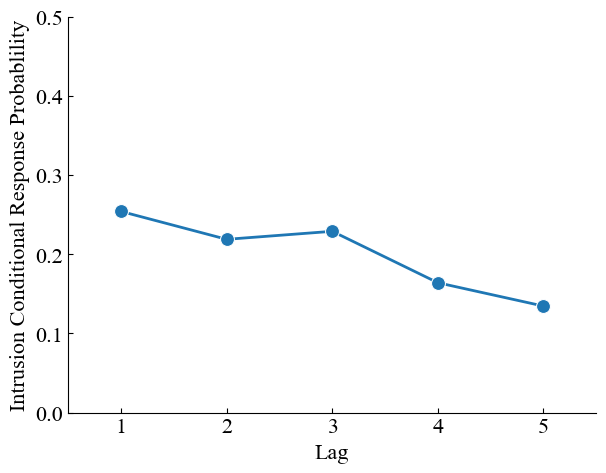

In [83]:
# plot
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_PLI_sess_lag, x="abs_list_lag", y="PLI_prob", linewidth=2, marker="o", markersize=10, errorbar=None)
plt.ylim([0, 0.5])
plt.xlim([0.5, 5.5])
plt.xticks(ticks=np.arange(1, 6))
plt.xlabel("Lag")
plt.ylabel("Intrusion Conditional Response Probablility")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("simu7_fig/simu7_PLI.pdf")

### ILI

In [84]:
# pick out ILI
df_ILI = df_simu.query("intrusion_type == 'ILI'").copy()
df_ILI["pos_lag"] = df_ILI["pos_lag"].astype(int)
df_ILI["pos_lag"] = pd.Categorical(df_ILI["pos_lag"], categories=np.concatenate([np.arange(-11, 0), np.arange(1, 12)]), ordered=True)
df_ILI

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,study_pos,test_dir,correct,resp_study_list,resp_study_pos,list_lag,pos_lag,intrusion_type
20,0,2,1399,570,4760,0.734549,SUBURB,142,3,1,False,2.0,4.0,0.0,1,ILI
24,0,3,611,266,2020,0.852658,FUDGE,962,9,1,False,3.0,11.0,0.0,2,ILI
45,0,5,290,453,4970,0.734068,CHEF,1371,7,1,False,5.0,8.0,0.0,1,ILI
144,1,2,353,481,2740,0.816978,COMET,790,2,0,False,2.0,11.0,0.0,9,ILI
152,1,3,100,780,1570,0.849685,BATHTUB,672,5,1,False,3.0,11.0,0.0,6,ILI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63854,498,13,112,549,2770,0.776893,BEE,970,7,0,False,13.0,1.0,0.0,-6,ILI
63880,499,1,1298,484,3920,0.698011,SHRINE,997,8,0,False,1.0,1.0,0.0,-7,ILI
63886,499,1,679,153,4740,0.745038,HAMBURGER,806,4,0,False,1.0,6.0,0.0,2,ILI
63898,499,3,825,866,1720,0.777499,LINEN,898,2,1,False,3.0,5.0,0.0,3,ILI


In [85]:
# session-wise, calculate ILI probability for each lag
def get_ILI_prob(df_tmp):

    # get possible ILI count
    possible_ILI_cnt = {}
    for pair_pos in df_tmp.study_pos:
        l_bound = -pair_pos
        r_bound = 11 - pair_pos
        for i in np.arange(l_bound, r_bound + 1):
            if i in possible_ILI_cnt:
                possible_ILI_cnt[i] += 1
            else:
                possible_ILI_cnt[i] = 1

    # get ILI count
    df_tmp_lag = df_tmp.groupby("pos_lag", observed=False)["test_item"].count().to_frame(name="ILI_cnt")

    # merge possible ILI count
    df_tmp_lag["possible_ILI_cnt"] = df_tmp_lag.index.map(possible_ILI_cnt).astype(float)
    df_tmp_lag["ILI_prob"] = df_tmp_lag["ILI_cnt"] / df_tmp_lag["possible_ILI_cnt"]

    return df_tmp_lag


df_ILI_sess_lag = df_ILI.groupby("session").apply(get_ILI_prob, include_groups=False).reset_index()
df_ILI_sess_lag["pos_lag"] = df_ILI_sess_lag["pos_lag"].astype(int)
df_ILI_sess_lag = df_ILI_sess_lag.query("pos_lag > -6 and pos_lag < 6").copy()
df_ILI_sess_lag

,session,pos_lag,ILI_cnt,possible_ILI_cnt,ILI_prob
6,0,-5,0,2.0,0.000000
7,0,-4,0,2.0,0.000000
8,0,-3,0,3.0,0.000000
9,0,-2,0,3.0,0.000000
10,0,-1,0,3.0,0.000000
...,...,...,...,...,...
10901,499,1,0,4.0,0.000000
10902,499,2,2,4.0,0.500000
10903,499,3,1,3.0,0.333333
10904,499,4,0,2.0,0.000000


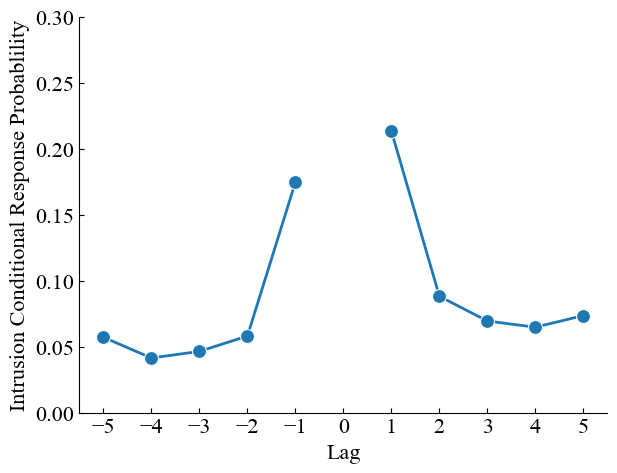

In [86]:
# plot
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

df_ILI_sess_lag["pos_lag"] = df_ILI_sess_lag["pos_lag"].astype(int)
sns.lineplot(data=df_ILI_sess_lag.query("-6 < pos_lag < 0"), x="pos_lag", y="ILI_prob", linewidth=2, marker="o", markersize=10, color="C0", errorbar=None)
sns.lineplot(data=df_ILI_sess_lag.query("0 < pos_lag < 6"), x="pos_lag", y="ILI_prob", linewidth=2, marker="o", markersize=10, color="C0", errorbar=None)
plt.ylim([0, 0.3])
plt.xticks(ticks=np.arange(-5, 6))
plt.xlabel("Lag")
plt.ylabel("Intrusion Conditional Response Probablility")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("simu7_fig/simu7_ILI.pdf")

### Err Check

In [87]:
lag_PLI_mean = df_PLI_sess_lag.groupby("abs_list_lag").PLI_prob.mean().values
df_ILI_sess_lag["pos_lag_int"] = df_ILI_sess_lag["pos_lag"].astype(int)  # avoid nan from category vairables
lag_ILI_mean = df_ILI_sess_lag.groupby("pos_lag_int").ILI_prob.mean().values
lag_PLI_mean, lag_ILI_mean

/var/folders/js/fb9kwys10ln8jgq1bxxqg0tr0000gn/T/ipykernel_81267/2200638241.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lag_PLI_mean = df_PLI_sess_lag.groupby("abs_list_lag").PLI_prob.mean().values


(array([0.2539657 , 0.2187567 , 0.22888532, 0.16393355, 0.13445874]),
 array([0.05703791, 0.04136722, 0.04635386, 0.05798131, 0.17459796,
        0.21322397, 0.08807607, 0.06936894, 0.06469232, 0.0735117 ]))

In [88]:
np.cov(np.arange(5), lag_PLI_mean)[0, 1] >= 0

False

In [89]:
np.any(np.diff(lag_ILI_mean[:5]) <= 0), np.any(np.diff(lag_ILI_mean[5:]) >= 0)

(True, True)

In [90]:
with open("simu7_data/simu7_gt.pkl", "rb") as f:
    p_correct_mean_gt = pickle.load(f)
    p_correct_se_gt = pickle.load(f)
    p_PLI_mean_gt = pickle.load(f)
    p_PLI_se_gt = pickle.load(f)
    p_ILI_mean_gt = pickle.load(f)
    p_ILI_se_gt = pickle.load(f)
    lag_PLI_mean_gt = pickle.load(f)
    lag_PLI_se_gt = pickle.load(f)
    lag_ILI_mean_gt = pickle.load(f)
    lag_ILI_se_gt = pickle.load(f)

In [91]:
lag_PLI_mean_gt, lag_ILI_mean_gt

(array([0.32678571, 0.24033447, 0.16269841, 0.19515306, 0.07502834]),
 array([0.04853509, 0.08652118, 0.08350867, 0.09478323, 0.1486024 ,
        0.21154655, 0.08574898, 0.10563333, 0.08867651, 0.0508634 ]))

In [92]:
wls_p_correct = get_wmse(p_correct_mean_gt, p_correct_mean, p_correct_se_gt)
wls_p_PLI = get_wmse(p_PLI_mean_gt, p_PLI_mean, p_PLI_se_gt)
wls_p_ILI = get_wmse(p_ILI_mean_gt, p_ILI_mean, p_ILI_se_gt)
wls_lag_PLI = get_wmse(lag_PLI_mean_gt, lag_PLI_mean, lag_PLI_se_gt) / len(lag_PLI_mean_gt)
wls_lag_ILI = get_wmse(lag_ILI_mean_gt, lag_ILI_mean, lag_ILI_se_gt) / len(lag_ILI_mean_gt)
err = wls_p_correct + wls_p_PLI + wls_p_ILI + wls_lag_PLI + wls_lag_ILI
err

0.08361510069548769

0.08361510069548769

In [93]:
wls_lag_PLI, wls_lag_ILI

(0.03783369518946398, 0.042521852915454995)